In [421]:
import pandas as pd
import numpy as np
from datetime import datetime
import requests

In [422]:
# set to show all the columns
pd.set_option('display.max_columns', None)

# Step 1 | Extract Manhattan inspection data and understand

## 1.1 Load NYC restaurants inspection data and extract Manhanttan restaurants

Visit the [DOHMH New York City Restaurant Inspection Results](https://data.cityofnewyork.us/Health/DOHMH-New-York-City-Restaurant-Inspection-Results/43nn-pn8j/about_data) and save the file as `DOHMH_New_York_City_Restaurant_Inspection_Results_20250527.csv`

In [423]:
# Load the file
df = pd.read_csv("DOHMH_New_York_City_Restaurant_Inspection_Results_20250527.csv")

# Filter all the Manhattan records
manhattan_insp_df = df[df['BORO'] == 'Manhattan'].copy()
manhattan_insp_df.reset_index(drop=True, inplace=True)

# Display the number of the records
summary_df = pd.DataFrame({
    'Area': ['Manhattan'],
    'Numbers of restaurant': ["{:,}".format(len(manhattan_insp_df))]
})
summary_df


,Area,Numbers of restaurant
0,Manhattan,"104,780"


In [424]:
manhattan_insp_df.head()

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,VIOLATION CODE,VIOLATION DESCRIPTION,CRITICAL FLAG,SCORE,GRADE,GRADE DATE,RECORD DATE,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location Point1
0,50084715,DEVOCION,Manhattan,25,EAST 20 STREET,10003.0,7182856180,Coffee/Tea,05/20/2025,Violations were cited in the following area(s).,06E,"Sanitized equipment or utensil, including in-u...",Critical,15.0,NaN,NaN,05/26/2025,Cycle Inspection / Initial Inspection,40.738984,-73.989308,105.0,2.0,5200.0,1016203.0,1.008490e+09,MN13,NaN
1,50133266,FRIEND OF A FARMER,Manhattan,68,WEST 71 STREET,10023.0,5162707961,American,05/15/2023,Violations were cited in the following area(s).,20-08,Failure to post or conspicuously post healthy ...,Not Critical,NaN,NaN,NaN,05/26/2025,Administrative Miscellaneous / Initial Inspection,40.776393,-73.978535,107.0,6.0,15700.0,1028585.0,1.011230e+09,MN14,NaN
2,50008894,IVAN RAMEN,Manhattan,25,CLINTON STREET,10002.0,6466783859,Japanese,12/05/2023,Violations were cited in the following area(s).,04M,Live roaches in facility's food or non-food area.,Critical,26.0,NaN,NaN,05/26/2025,Cycle Inspection / Initial Inspection,40.720569,-73.984311,103.0,2.0,3001.0,1004251.0,1.003500e+09,MN27,NaN
3,50145148,SABOR Y PASION EN LA COCINA,Manhattan,1552,SAINT NICHOLAS AVENUE,10040.0,6466495032,Latin American,03/11/2025,Violations were cited in the following area(s).,20-06,Current letter grade or Grade Pending card not...,Not Critical,NaN,NaN,NaN,05/26/2025,Administrative Miscellaneous / Second Complian...,40.853409,-73.930722,112.0,10.0,26900.0,1063808.0,1.021580e+09,MN35,NaN
4,50014481,MAMAN,Manhattan,239,CENTRE STREET,10013.0,2122260700,French,02/08/2023,Violations were cited in the following area(s).,04K,Evidence of rats or live rats in establishment...,Critical,11.0,A,02/08/2023,05/26/2025,Cycle Inspection / Re-inspection,40.720185,-73.998200,102.0,1.0,4500.0,1007006.0,1.004720e+09,MN24,NaN


In [425]:
# Save to csv and ignore the original index from the DOHMH_New_York_City_Restaurant_Inspection_Results_20250527.csv
# File has already been saved; this line is now commented out to prevent overwriting
# manhattan_insp_df.to_csv("Inspection_20250527_step1.1.csv", index=False)

## 1.2 Extract unique values based on Camis

According to https://data.cityofnewyork.us/Health/DOHMH-New-York-City-Restaurant-Inspection-Results/43nn-pn8j/about_data

CAMIS is an unique identifier for the entity (restaurant); 10-digit integer, static per restaurant permit

In [426]:
duplicate_camis = manhattan_insp_df['CAMIS'].duplicated().sum()
duplicate_camis

np.int64(92869)

In [427]:
camis_unique = manhattan_insp_df['CAMIS'].nunique()
camis_unique

11911

There are records with duplicate CAMIS in the manhattan_insp_df, which means there are restaurant have more than 1 inspection records in the dataframe.

In [428]:
camis_counts = manhattan_insp_df['CAMIS'].value_counts()
camis_counts.head()


CAMIS
40365904    79
50123073    69
50040296    69
50089474    68
41406895    65
Name: count, dtype: int64

The table above shows the restaurants with the highest number of inspection records.

In [429]:
# View the score and grade for each inspection of each restaurant
score_by_inspection = manhattan_insp_df[['CAMIS', 'INSPECTION DATE', 'SCORE','GRADE']].copy()

# Sort by restaurant ID and inspection date 
score_by_inspection.sort_values(by=['CAMIS', 'INSPECTION DATE'], inplace=True)

# Display the first few rows
score_by_inspection.head(10)


,CAMIS,INSPECTION DATE,SCORE,GRADE
47694,30191841,02/20/2025,10.0,A
92595,30191841,02/20/2025,10.0,A
23608,30191841,04/23/2023,10.0,A
35255,30191841,04/23/2023,10.0,A
34396,30191841,11/20/2024,24.0,NaN
39749,30191841,11/20/2024,24.0,NaN
54199,30191841,11/20/2024,24.0,NaN
70575,30191841,11/20/2024,24.0,NaN
91037,30191841,11/20/2024,24.0,NaN
104522,30191841,11/20/2024,24.0,NaN


According to https://www.nyc.gov/site/doh/services/restaurant-grades.page,

The Health Department conducts unannounced inspections of restaurants at least once a year. Inspectors check that restaurants comply with food safety rules.

Violations of food safety rules carry point values, and a restaurant’s score corresponds to a letter grade. **The lower the score, the better the grade.**

According to https://www.nyc.gov/assets/doh/downloads/pdf/rii/restaurant-grading-faq.pdf 

"Restaurants with a score between 0 and 13 points earn an A, those with 14 to 27 points receive a B and those with 28 or more a C. Two types of inspections result in a letter grade: initial
inspections for which the restaurant earns an A and reinspections that result in an A, B or C. 

A restaurant has two chances to earn an A in every inspection cycle. If it doesn’t earn an A on the first inspection, it’s scored but ungraded. An inspector goes back to the restaurant unannounced, typically within a month, to inspect it again and the re-inspection is graded. If the grade is a B or C, the restaurant will receive a grade card and a grade pending card. It
can post either card until it has an opportunity to be heard at
the Office of Administrative Trials and Hearings Health
Tribunal.
Until a restaurant has a graded inspection, it is listed as Not
Yet Graded on the Health Department website. "

In [430]:
manhattan_insp_df.dtypes

CAMIS                      int64
DBA                       object
BORO                      object
BUILDING                  object
STREET                    object
ZIPCODE                  float64
PHONE                     object
CUISINE DESCRIPTION       object
INSPECTION DATE           object
ACTION                    object
VIOLATION CODE            object
VIOLATION DESCRIPTION     object
CRITICAL FLAG             object
SCORE                    float64
GRADE                     object
GRADE DATE                object
RECORD DATE               object
INSPECTION TYPE           object
Latitude                 float64
Longitude                float64
Community Board          float64
Council District         float64
Census Tract             float64
BIN                      float64
BBL                      float64
NTA                       object
Location Point1          float64
dtype: object

In [431]:
# Keep unique restaurants 'CAMIS' and the latest inspection records

# ensure type of INSPECTION DATE is datetime
manhattan_insp_df['INSPECTION DATE'] = pd.to_datetime(manhattan_insp_df['INSPECTION DATE'], errors='coerce')


# remove spaces in CAMIS
manhattan_insp_df['CAMIS'] = manhattan_insp_df['CAMIS'].astype(str).str.strip()

# group by CAMIS, remain latest INSPECTION DATE 
manhattan_latest_insp_df = (
    manhattan_insp_df.sort_values(['CAMIS', 'INSPECTION DATE'], ascending=[True, False])
                     .drop_duplicates(subset='CAMIS', keep='first')
                     .reset_index(drop=True)
)



In [432]:
print("Original records:", len(manhattan_insp_df))
print("Latest records:", len(manhattan_latest_insp_df))


Original records: 104780
Latest records: 11911


In [433]:
manhattan_insp_df['INSPECTION DATE'] = pd.to_datetime(manhattan_insp_df['INSPECTION DATE'], errors='coerce')
manhattan_insp_df['inspection_day'] = manhattan_insp_df['INSPECTION DATE'].dt.date


In [434]:
inspection_counts = manhattan_insp_df[['CAMIS', 'inspection_day']].drop_duplicates()
inspection_counts = inspection_counts.groupby('CAMIS').size().reset_index(name='inspection_times')


In [435]:
# flag critical
manhattan_insp_df['is_violation'] = manhattan_insp_df['CRITICAL FLAG'].fillna('').str.upper() == 'CRITICAL'

# group by day
violation_by_day = (
    manhattan_insp_df.groupby(['CAMIS', 'inspection_day'])['is_violation']
    .max()  
    .reset_index()
)

# counts violation days
violation_counts = violation_by_day[violation_by_day['is_violation']].groupby('CAMIS').size().reset_index(name='violation_times')


In [436]:
# ensure CAMIS is the same format
manhattan_latest_insp_df['CAMIS'] = manhattan_latest_insp_df['CAMIS'].astype(str).str.strip()
inspection_counts['CAMIS'] = inspection_counts['CAMIS'].astype(str).str.strip()
violation_counts['CAMIS'] = violation_counts['CAMIS'].astype(str).str.strip()

# merge two columns
manhattan_latest_insp_df = manhattan_latest_insp_df.merge(inspection_counts, on='CAMIS', how='left')
manhattan_latest_insp_df = manhattan_latest_insp_df.merge(violation_counts, on='CAMIS', how='left')

# fill missing value as 0
manhattan_latest_insp_df['violation_times'] = manhattan_latest_insp_df['violation_times'].fillna(0).astype(int)


## 1.3 Check missing values

In [437]:
# Check missing values for the Manhattan dataset
missing_info = manhattan_insp_df.isna().sum().to_frame(name='Missing_Count')
missing_info['Missing_Percent'] = ((missing_info['Missing_Count'] / len(manhattan_insp_df)) * 100).round(2)
missing_info

,Missing_Count,Missing_Percent
CAMIS,0,0.00
DBA,1,0.00
BORO,0,0.00
BUILDING,82,0.08
STREET,0,0.00
ZIPCODE,1518,1.45
PHONE,9,0.01
CUISINE DESCRIPTION,1302,1.24
INSPECTION DATE,0,0.00
ACTION,1302,1.24


In [438]:
# Check missing values for the Manhattan dataset with latest inspection
missing_info_unique = manhattan_latest_insp_df.isna().sum().to_frame(name='Missing_Count')
missing_info_unique['Missing_Percent'] = ((missing_info['Missing_Count'] / len(manhattan_latest_insp_df)) * 100).round(2)
missing_info_unique

,Missing_Count,Missing_Percent
CAMIS,0,0.00
DBA,1,0.01
BORO,0,0.00
BUILDING,18,0.69
STREET,0,0.00
ZIPCODE,212,12.74
PHONE,2,0.08
CUISINE DESCRIPTION,1302,10.93
INSPECTION DATE,0,0.00
ACTION,1302,10.93


It's the same number as missing values in column **CUISINE DESCRIPTION** and **ACTION**. Since we need to be responsible for the restaurants our app recommends, we decided to drop those that have not been insepected.

## 1.4 Drop the restaurants that have not been inspected(as of 27 May 2025)

In [439]:
# Inspection dates of 1/1/1900 mean an establishment has not yet had an inspection
not_inspected_count = (manhattan_latest_insp_df['INSPECTION DATE'] == '01/01/1900').sum()
print("Number of establishments not yet inspected:", not_inspected_count)


Number of establishments not yet inspected: 1302


In [440]:
# Get original number of rows
original_count = len(manhattan_latest_insp_df)

# Drop rows where INSPECTION DATE is '01/01/1900'
filtered_df = manhattan_latest_insp_df[manhattan_latest_insp_df['INSPECTION DATE'] != '01/01/1900']

# Get new number of rows
filtered_count = len(filtered_df)

manhattan_latest_insp_df = filtered_df

# Print comparison
print(f"Rows before drop: {original_count}")
print(f"Rows after drop: {filtered_count}")
print(f"Rows dropped: {original_count - filtered_count}")


Rows before drop: 11911
Rows after drop: 10609
Rows dropped: 1302


## 1.5 Drop constant column and meaningless column

In [441]:
# Drop Location Point1 and BORO
manhattan_latest_insp_df.drop(columns=['Location Point1', 'BORO'], inplace=True)


In [442]:
# Check the missing value again after dropping

missing_info_unique = manhattan_latest_insp_df.isna().sum().to_frame(name='Missing_Count')
missing_info_unique['Missing_Percent'] = ((missing_info['Missing_Count'] / len(manhattan_latest_insp_df)) * 100).round(2)
missing_info_unique

,Missing_Count,Missing_Percent
CAMIS,0,0.00
DBA,0,0.01
BUILDING,13,0.77
STREET,0,0.00
ZIPCODE,170,14.31
PHONE,2,0.08
CUISINE DESCRIPTION,0,12.27
INSPECTION DATE,0,0.00
ACTION,0,12.27
VIOLATION CODE,329,20.65


In [443]:
# File has already been saved; this line is now commented out to prevent overwriting
# manhattan_latest_insp_df.to_csv('Inspection_latest_Results_cleaned_step1.csv')


In [444]:
# This info is prepared for potential use
# neighborhoods = ['Midtown West', 'Greenwich Village', 'East Harlem', 'Upper East Side', 'Midtown East',
#                  'Gramercy', 'Little Italy', 'Chinatown', 'SoHo', 'Harlem',
#                  'Upper West Side', 'Tribeca', 'Garment District', 'Stuyvesant Town', 'Financial District',
#                  'Chelsea', 'Morningside Heights', 'Times Square', 'Murray Hill', 'East Village',
#                  'Lower East Side', 'Hell\s Kitchen', 'Central Park']

# Step 2 | Match with Yelp

In [ ]:
# This Yelp dataset was originally processed in data/data_exploration.
# To avoid confusion in case the source file changes, a copy was made in the current folder.

yelp_df = pd.read_csv("yelp_manhattan_step2_18731.csv")

In [446]:
import re

# normalize restaurants names, remove deminaters and use only lowercase letters
def normalize_name(name):
    if pd.isna(name):
        return ""
    return re.sub(r'[\W_]+', '', name).lower()

In [447]:
from datetime import datetime

def save_dataframe_with_timestamp(df, prefix: str, suffix: str = ".csv", index=False):
    """Save a DataFrame to CSV with a timestamped filename."""
    now = datetime.now()
    timestamp = now.strftime("%Y%m%d_%H%M%S")
    filename = f"{prefix}_{timestamp}_{suffix}"
    df.to_csv(filename, index=index)
    return filename


## 2.1 Name-based matching

In [448]:
yelp_df['normalized_name'] = yelp_df['name'].apply(normalize_name)
manhattan_latest_insp_df['normalized_name'] = manhattan_latest_insp_df['DBA'].apply(normalize_name)

In [449]:
yelp_dedup = yelp_df.drop_duplicates(subset='normalized_name', keep='first')
yelp_name_to_coord = yelp_dedup.set_index('normalized_name')[['coordinates.latitude', 'coordinates.longitude']].to_dict('index')

In [450]:
def find_yelp_coords(norm_name):
    if norm_name in yelp_name_to_coord:
        coords = yelp_name_to_coord[norm_name]
        return pd.Series([True, coords['coordinates.latitude'], coords['coordinates.longitude']])
    else:
        return pd.Series([False, None, None])


manhattan_latest_insp_df[['in_yelp_by_name', 'yelp_lat', 'yelp_lon']] = manhattan_latest_insp_df['normalized_name'].apply(find_yelp_coords)



### Testing with coordinations

In [451]:
from math import radians, cos, sin, asin, sqrt
# https://gist.github.com/rochacbruno/2883505?permalink_comment_id=2615334
def haversine(lat1, lon1, lat2, lon2):
    if None in [lat1, lon1, lat2, lon2]:
        return None
    # Earth radius in meter
    R = 6371000
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return R * c



In [452]:
manhattan_latest_insp_df['distance_meters'] = manhattan_latest_insp_df.apply(
    lambda row: haversine(row['Latitude'], row['Longitude'], row['yelp_lat'], row['yelp_lon'])
    if row['in_yelp_by_name'] else None,
    axis=1
)

In [453]:
def classify_match(row):
    if row['in_yelp_by_name'] is True:
        if row['distance_meters'] is not None and row['distance_meters'] <= 100:
            return 'high'
        else:
            return 'low'
    else:
        return None

manhattan_latest_insp_df['yelp_match_confidence'] = manhattan_latest_insp_df.apply(classify_match, axis=1)


In [454]:
def compute_confidence_ratio(df, column: str = 'yelp_match_confidence'):
    """
    Compute percentage breakdown of match confidence levels,
    and print number of rows where confidence is 'high'.

    Returns:
        pd.DataFrame: Summary with columns [Confidence Level, Count, Proportion (%)]
    """
    summary = (
        df[column]
        .value_counts(dropna=False)
        .rename_axis('Confidence Level')
        .reset_index(name='Count')
    )
    total = summary['Count'].sum()
    summary['Proportion (%)'] = (summary['Count'] / total * 100).round(2)


    return summary



In [455]:
compute_confidence_ratio(manhattan_latest_insp_df)


,Confidence Level,Count,Proportion (%)
0,None,5521,52.04
1,high,3064,28.88
2,low,2024,19.08


In [456]:
def summarize_column(df, column_name: str) -> pd.DataFrame:
    """
    Summarize a boolean column: count and proportion of True/False/NaN values.
    """
    summary = (
        df[column_name]
        .value_counts(dropna=False)
        .rename_axis('Value')
        .reset_index(name='Count')
    )
    total = summary['Count'].sum()
    summary['Proportion (%)'] = (summary['Count'] / total * 100).round(2)
    return summary


In [457]:
summarize_column(manhattan_latest_insp_df, 'in_yelp_by_name')

,Value,Count,Proportion (%)
0,False,5521,52.04
1,True,5088,47.96


In [458]:
# save_dataframe_with_timestamp(manhattan_latest_insp_df, "Manhattan_Restaurant_Latest_Inspection_inYelp_byName")

## 2.2 Phone-based matching

In [459]:
import re
def clean_us_phone_safe(phone):
    # If input is a float, convert it to a plain integer string without decimals
    try:
        if isinstance(phone, float):
            phone = '{:.0f}'.format(phone)   # Prevent decimal formatting
    except:
        pass
    digits = re.sub(r'\D', '', str(phone))
    
    if len(digits) == 11 and digits.startswith('1'):
        return digits[1:]
    if len(digits) == 10:
        return digits
    return None


In [460]:
yelp_df['normalized_phone'] = yelp_df['phone'].apply(clean_us_phone_safe)
manhattan_latest_insp_df['normalized_phone'] = manhattan_latest_insp_df['PHONE'].astype(str).apply(lambda x: re.sub(r'\D', '', x))


In [461]:
# save_dataframe_with_timestamp(yelp_df,"Yelp")

In [462]:
yelp_phone_set = set(yelp_df['normalized_phone'].dropna())

# match by phone number
manhattan_latest_insp_df['in_yelp_by_phone'] = manhattan_latest_insp_df['normalized_phone'].apply(
    lambda x: x in yelp_phone_set if x else False
)

In [463]:
summarize_column(manhattan_latest_insp_df, 'in_yelp_by_phone')

,Value,Count,Proportion (%)
0,False,6286,59.25
1,True,4323,40.75


In [464]:
manhattan_latest_insp_df['in_yelp_by_name_or_phone'] = (
    manhattan_latest_insp_df['in_yelp_by_name'].fillna(False) | manhattan_latest_insp_df['in_yelp_by_phone'].fillna(False)
)


In [465]:
summarize_column(manhattan_latest_insp_df, 'in_yelp_by_name_or_phone')

,Value,Count,Proportion (%)
0,True,6695,63.11
1,False,3914,36.89


### Testing with coordinations

In [466]:
# drop the column from previous steps
manhattan_latest_insp_df.drop(columns=[
    'distance_meters',
    'yelp_match_confidence'
], inplace=True, errors='ignore')


In [467]:
# map phone with coordinations
yelp_phone_coord_map = yelp_df.dropna(subset=['normalized_phone']) \
    .drop_duplicates(subset='normalized_phone', keep='first') \
    .set_index('normalized_phone')[['coordinates.latitude', 'coordinates.longitude']] \
    .to_dict('index')

# fill yelp_lat/yelp_lon if in_yelp_by_phone == True (overwrite regardless of existing values)
# overwrite because some of the chained restaurants may mismatch by names
def overwrite_coords_by_phone(row):
    if row['in_yelp_by_phone']:
        coords = yelp_phone_coord_map.get(row['normalized_phone'])
        if coords:
            return pd.Series([coords['coordinates.latitude'], coords['coordinates.longitude']])
    return pd.Series([row['yelp_lat'], row['yelp_lon']])

# apply update
manhattan_latest_insp_df[['yelp_lat', 'yelp_lon']] = manhattan_latest_insp_df.apply(overwrite_coords_by_phone, axis=1)


In [468]:
# distance
manhattan_latest_insp_df['distance_by_name_or_phone'] = manhattan_latest_insp_df.apply(
    lambda row: haversine(row['Latitude'], row['Longitude'], row['yelp_lat'], row['yelp_lon'])
    if row['in_yelp_by_name_or_phone'] and (row['Latitude'] != 0 and row['Longitude'] != 0)
    else None,
    axis=1
)

# confidence
def classify_combined_match(row):
    if row['in_yelp_by_name_or_phone']:
        # if inspection does not have coordinations
        if row['Latitude'] == 0 and row['Longitude'] == 0:
            return 'high'
        
        if pd.notnull(row['distance_by_name_or_phone']):
            return 'high' if row['distance_by_name_or_phone'] <= 100 else 'low'
        # high: 50->4293 100->4768 200->4875
        else:
            return 'missing_coords'
    return None

manhattan_latest_insp_df['yelp_combined_match_confidence'] = manhattan_latest_insp_df.apply(classify_combined_match, axis=1)


In [469]:
compute_confidence_ratio(manhattan_latest_insp_df, column='yelp_combined_match_confidence')


,Confidence Level,Count,Proportion (%)
0,high,5215,49.16
1,None,3914,36.89
2,low,1476,13.91
3,missing_coords,4,0.04


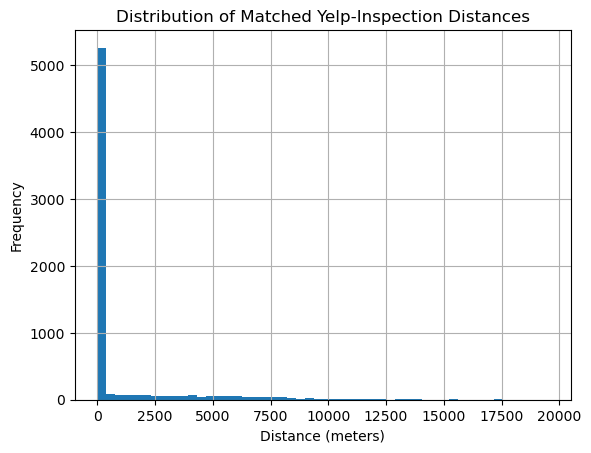

In [470]:
import matplotlib.pyplot as plt

manhattan_latest_insp_df[manhattan_latest_insp_df['distance_by_name_or_phone'].notnull()]['distance_by_name_or_phone'].hist(bins=50)
plt.xlabel("Distance (meters)")
plt.ylabel("Frequency")
plt.title("Distribution of Matched Yelp-Inspection Distances")
plt.show()


In [471]:
# File has already been saved; this line is now commented out to prevent overwriting
# save_dataframe_with_timestamp(manhattan_latest_insp_df, "Inspection_inYelp")

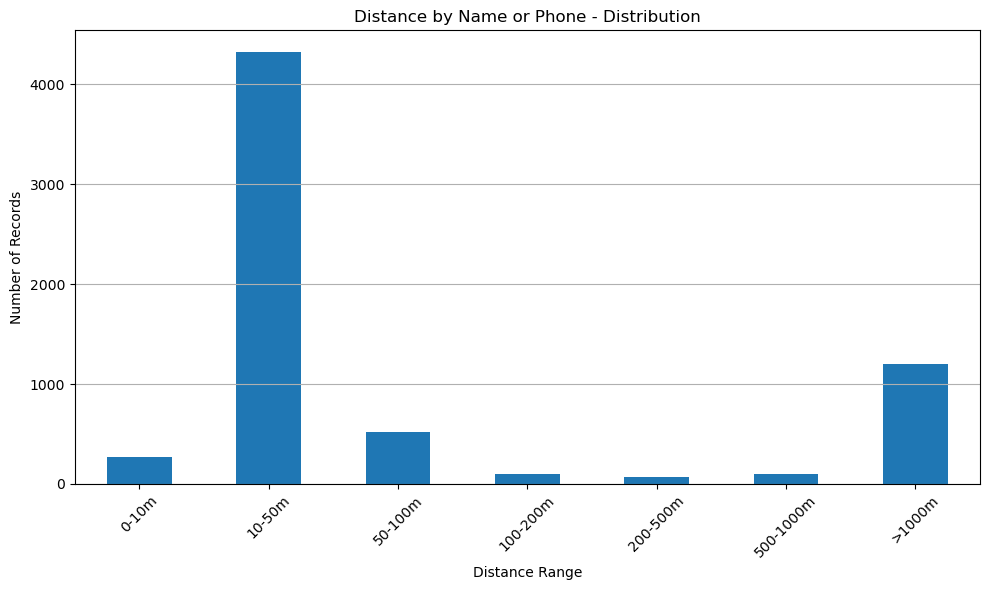

In [472]:
import pandas as pd
import matplotlib.pyplot as plt

# set up bins
bins = [0, 10, 50, 100, 200, 500, 1000, float('inf')]
labels = ['0-10m', '10-50m', '50-100m', '100-200m', '200-500m', '500-1000m', '>1000m']

# group by distance
valid_distances = manhattan_latest_insp_df['distance_by_name_or_phone'].dropna()
distance_groups = pd.cut(valid_distances, bins=bins, labels=labels)
distance_counts = distance_groups.value_counts().sort_index()

# visualize
plt.figure(figsize=(10, 6))
distance_counts.plot(kind='bar')
plt.title('Distance by Name or Phone - Distribution')
plt.xlabel('Distance Range')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()



In [473]:
distance_df = distance_counts.reset_index()
distance_df.columns = ['Distance Range', 'Count']
distance_df

,Distance Range,Count
0,0-10m,269
1,10-50m,4326
2,50-100m,518
3,100-200m,104
4,200-500m,72
5,500-1000m,101
6,>1000m,1199


## 2.3 Check distance > 1000m, Brand missing in yelp_df

In [474]:
# Filter rows where 'distance_by_name_or_phone' > 1000
far_matches = manhattan_latest_insp_df[manhattan_latest_insp_df['distance_by_name_or_phone'] > 1000]

# Save to CSV
# far_matches.to_csv("far_matches_over_1000.csv", index=False)


After reviewing the results of far matches, we found that some brands were missing entries in the yelp_df, which resulted in matches lacking phone-based sources and relying only on name-based matching, leading to lower confidence.

In [475]:
def count_brand_occurrences(brand_keyword: str, insp_df: pd.DataFrame, yelp_df: pd.DataFrame) -> None:
    """
    Count the number of records containing the brand keyword in both inspection and Yelp datasets.

    Args:
        brand_keyword (str): The brand name or keyword to search for (e.g., 'Starbucks').
        insp_df (pd.DataFrame): The inspection dataset.
        yelp_df (pd.DataFrame): The Yelp dataset.

    Prints:
        The number of matching records in both datasets.
    """
    # Filter inspection dataset
    brand_in_insp = insp_df[
        insp_df['DBA'].str.contains(brand_keyword, case=False, na=False)
    ]

    # Filter Yelp dataset
    brand_in_yelp = yelp_df[
        yelp_df['name'].str.contains(brand_keyword, case=False, na=False)
    ]

    # Output
    print(f"{brand_keyword} in inspection dataset:", len(brand_in_insp))
    print(f"{brand_keyword} in Yelp dataset:", len(brand_in_yelp))

count_brand_occurrences('starbucks', manhattan_latest_insp_df, yelp_df)



starbucks in inspection dataset: 196
starbucks in Yelp dataset: 5


In [476]:
# Filter rows where distance_by_name_or_phone > 100
far_matches = manhattan_latest_insp_df[manhattan_latest_insp_df['distance_by_name_or_phone'] > 100]

# Count the frequency of each DBA in these far matches
dba_counts = far_matches['DBA'].value_counts()

# Show top 10 most frequent DBA names
dba_counts.head(30)

# Optionally, check some other patterns
# For example: see unique values of 'normalized_phone', 'normalized_name', or address-related columns
# print(far_matches[['DBA', 'normalized_name', 'normalized_phone', 'BUILDING', 'STREET']].head(20))


DBA
STARBUCKS                 132
DUNKIN                     85
JUST SALAD                 28
DUNKIN'                    27
PRET A MANGER              23
SUBWAY                     23
SWEETGREEN                 22
BLANK STREET COFFEE        19
JOE & THE JUICE            19
MCDONALD'S                 18
DUNKIN DONUTS              14
LE PAIN QUOTIDIEN          14
SHAKE SHACK                14
JOE COFFEE                 12
BLUESTONE LANE             11
LE CAFE COFFEE             10
BIRCH COFFEE               10
MATTO ESPRESSO             10
TACO BELL                   9
787 COFFEE                  9
THINK COFFEE                9
CHIPOTLE MEXICAN GRILL      9
MAMAN                       9
7TH STREET BURGER           8
LITTLE ITALY PIZZA          7
JUICE PRESS                 7
POKE BOWL                   7
WONDER                      7
WENDY'S                     6
DOS TOROS TAQUERIA          6
Name: count, dtype: int64

In [477]:
def get_brand_counts(brand_keyword: str, insp_df: pd.DataFrame, yelp_df: pd.DataFrame) -> dict:
    """
    Return count of brand_keyword in both datasets for later aggregation.
    """
    count_in_insp = insp_df['DBA'].str.contains(brand_keyword, case=False, na=False).sum()
    count_in_yelp = yelp_df['name'].str.contains(brand_keyword, case=False, na=False).sum()
    return {
        'brand': brand_keyword,
        'insp_count': count_in_insp,
        'yelp_count': count_in_yelp
    }



# filter dba_counts>1
common_dbas = dba_counts[dba_counts > 1].index.tolist()

results = []
for brand in common_dbas:
    result = get_brand_counts(brand, manhattan_latest_insp_df, yelp_df)
    results.append(result)


brand_df = pd.DataFrame(results)

# filter inspection count > yelp count
brand_df = brand_df[brand_df['insp_count'] > brand_df['yelp_count']]

# sort by insp_count
brand_df = brand_df.sort_values(by='insp_count', ascending=False).reset_index(drop=True)

# Add a column to estimate potential gain in high-confidence matches
brand_df['potential_gain'] = brand_df['insp_count'] - brand_df['yelp_count']

In [478]:
# Next action: if we need to rely on yelp data, we will fetch data that currently missing in the yelp_df
brand_df.to_csv("Brand needs fetching.csv")

In [479]:
brand_df_modified = pd.read_csv("Brand needs fetching.csv")
total_potential_gain = brand_df_modified['potential_gain'].sum()
print("Potential gain after fetching more yelp_data: ",total_potential_gain)


Potential gain after fetching more yelp_data:  754


## 2.4 Fill missing latitude and longitude using yelp data

In [480]:

# Step 1: Make a copy of the original dataframe to compare before and after
before_fill_df = manhattan_latest_insp_df.copy()

# Step 2: Define a function to fill missing latitude and longitude using Yelp data
def fill_missing_coords(row):
    phone = row['normalized_phone']
    coords = yelp_phone_coord_map.get(phone)

    # Only attempt to fill if match by phone and Yelp has coordinates
    if row['in_yelp_by_phone'] and coords:
        lat, lon = row['Latitude'], row['Longitude']
        new_lat, new_lon = coords['coordinates.latitude'], coords['coordinates.longitude']

        lat_missing = pd.isna(lat) or lat == 0
        lon_missing = pd.isna(lon) or lon == 0

        updated_lat = new_lat if lat_missing else lat
        updated_lon = new_lon if lon_missing else lon

        if lat_missing or lon_missing:
            return pd.Series([updated_lat, updated_lon, 'filled_by_yelp'])

    return pd.Series([row['Latitude'], row['Longitude'], 'original'])


# Step 3: Build a lookup dictionary from Yelp data: phone -> coordinates
yelp_phone_coord_map = yelp_df.dropna(subset=['normalized_phone']) \
    .drop_duplicates(subset='normalized_phone', keep='first') \
    .set_index('normalized_phone')[['coordinates.latitude', 'coordinates.longitude']] \
    .to_dict('index')

# Step 4: Apply the fill function to update coordinates and track the source
manhattan_latest_insp_df[['Latitude', 'Longitude', 'coord_source']] = manhattan_latest_insp_df.apply(
    fill_missing_coords,
    axis=1
)

# Step 5: Count how many rows had their coordinates changed
num_changed = ((before_fill_df['Latitude'] != manhattan_latest_insp_df['Latitude']) |
               (before_fill_df['Longitude'] != manhattan_latest_insp_df['Longitude'])).sum()


# Show the count of each coordinate source type
manhattan_latest_insp_df['coord_source'].value_counts()


coord_source
original          10538
filled_by_yelp       71
Name: count, dtype: int64

In [483]:
before_fill_df
missing_coords_before = before_fill_df[
    (before_fill_df['Latitude'].isna() | (before_fill_df['Latitude'] == 0)) |
    (before_fill_df['Longitude'].isna() | (before_fill_df['Longitude'] == 0))
]

print(f"Remaining rows with missing coordinates: {len(missing_coords_before)}")

Remaining rows with missing coordinates: 193


In [485]:
# Count rows where Latitude or Longitude is still 0 or NaN
missing_coords = manhattan_latest_insp_df[
    (manhattan_latest_insp_df['Latitude'].isna() | (manhattan_latest_insp_df['Latitude'] == 0)) |
    (manhattan_latest_insp_df['Longitude'].isna() | (manhattan_latest_insp_df['Longitude'] == 0))
]

print(f"Remaining rows with missing coordinates: {len(missing_coords)}")


Remaining rows with missing coordinates: 122


In [481]:
manhattan_latest_insp_df.to_csv("Inspection_latest_Results_cleaned_step2.csv")